In [ ]:
# installing all required packages

#installing this library so we can detect and remove emojis in our text data
!pip install emoji
#installing this library because it is a powerful NLP toolkit used for text preprocessing
!pip install spacy
#installing this ML library for classification & regression
!pip install xgboost
#installing TensorFlow in quiet mode. It is used for deep learning models
!pip install -q tensorflow
#installing lime because it is used for model explainability (helps explain predictions)
!pip install -q lime

In [ ]:
#importing important libraries which are required for this project
import pandas as pd  #working with datasets easily
import numpy as np  #numerical operations, arrays, math functions
import matplotlib.pyplot as plt #basic plotting library for graphs
import seaborn as sns #better looking visualizations
import tensorflow as tf #deep learning framework here used for neural newtwork model
import scipy.sparse as sp #for handling sparse matrices
import re #regular expression for text cleaning
import emoji #detecting and removing emojis from text
import string #gives access to punuation characters
import spacy #library for tokenizing and lemmatizing
import nltk # used for stopwords and stemming
import joblib #saves and loads ml models easily
import os #for interaction with system files and directories
import xgboost as xgb #gradient boosting library
from sklearn.preprocessing import LabelEncoder  #it converts text labels into numbers
from sklearn.preprocessing import MinMaxScaler #scales numeric features to 0–1
from sklearn.feature_extraction.text import TfidfVectorizer #converts text to numerical features
from sklearn.model_selection import train_test_split #splits data into train and test sets
from sklearn.utils import compute_class_weight #handles imbalanced classes
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #evaluation metrics to check model performance
from sklearn.metrics import precision_score, recall_score, f1_score, cohen_kappa_score #evaluation metrics to check model performance
from sklearn.model_selection import GridSearchCV #for hyperparameter tuning
from sklearn.metrics import roc_auc_score, roc_curve #for ROC curve and AUC score
from wordcloud import WordCloud, STOPWORDS #used to generate word clouds
from collections import Counter #helps count word frequencies
from nltk.corpus import stopwords #list of common stopwords
from nltk.stem import SnowballStemmer #stemming text to base form
from xgboost import XGBClassifier #XGBoost classifier model
from tensorflow.keras import layers, models, callbacks #building deep learning models
from IPython.display import HTML, display #show HTML,tables,styled output in notebooks
from lime.lime_tabular import LimeTabularExplainer #explain model predictions using LIME

In [ ]:
twitter_analysis = pd.read_csv("/content/drive/MyDrive/CIC_Truth_Seeker_Model_Dataset_2023.csv", encoding="latin1", encoding_errors="ignore")

In [ ]:
#seeing 1st 5 rows of data
twitter_analysis.head()

,Unnamed: 0,author,statement,target,BinaryNumTarget,manual_keywords,tweet,5_label_majority_answer,3_label_majority_answer
0,0,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@POTUS Biden Blunders - 6 Month Update\n\nInfl...,Mostly Agree,Agree
1,1,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,NO MAJORITY,Agree
2,2,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",THE SUPREME COURT is siding with super rich pr...,Agree,Agree
3,3,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@POTUS Biden Blunders\n\nBroken campaign promi...,Mostly Agree,Agree
4,4,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@OhComfy I agree. The confluence of events rig...,Agree,Agree


In [ ]:
#seeing last 5 rows of data
twitter_analysis.tail()

,Unnamed: 0,author,statement,target,BinaryNumTarget,manual_keywords,tweet,5_label_majority_answer,3_label_majority_answer
134193,134193,Tom Kertscher,Joe Bidens great-grandfather Joseph J. Biden w...,False,0.0,"Biden, great grandfather, slave owner",Joe Biden's family owned African slaves....\n\...,Mostly Agree,Agree
134194,134194,Tom Kertscher,Joe Bidens great-grandfather Joseph J. Biden w...,False,0.0,"Biden, great grandfather, slave owner","Joe Bidens great, great grandfather was a slav...",Agree,Agree
134195,134195,Tom Kertscher,Joe Bidens great-grandfather Joseph J. Biden w...,False,0.0,"Biden, great grandfather, slave owner","@ChevyChaseToGo ""Joe Bidens great-grandfather ...",Mostly Agree,Agree
134196,134196,Tom Kertscher,Joe Bidens great-grandfather Joseph J. Biden w...,False,0.0,"Biden, great grandfather, slave owner",@JoeBiden Facts are Bidens VP Kamala Harris Gr...,NO MAJORITY,Agree
134197,134197,Tom Kertscher,Joe Bidens great-grandfather Joseph J. Biden w...,False,0.0,"Biden, great grandfather, slave owner",@sunny Yes representation matters. Did you kno...,Agree,Agree


In [ ]:
#shape of dataset
twitter_analysis.shape

(134198, 9)

In [ ]:
#seeing what all columns our dataset has
twitter_analysis.columns

Index(['Unnamed: 0', 'author', 'statement', 'target', 'BinaryNumTarget',
       'manual_keywords', 'tweet', '5_label_majority_answer',
       '3_label_majority_answer'],
      dtype='object')

In [ ]:
#seeing info of data
twitter_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134198 entries, 0 to 134197
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               134198 non-null  int64  
 1   author                   134198 non-null  object 
 2   statement                134198 non-null  object 
 3   target                   134198 non-null  bool   
 4   BinaryNumTarget          134198 non-null  float64
 5   manual_keywords          134198 non-null  object 
 6   tweet                    134198 non-null  object 
 7   5_label_majority_answer  134198 non-null  object 
 8   3_label_majority_answer  134198 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 8.3+ MB


In [ ]:
# Checking for missing values
twitter_analysis.isnull().sum()

,0
Unnamed: 0,0
author,0
statement,0
target,0
BinaryNumTarget,0
manual_keywords,0
tweet,0
5_label_majority_answer,0
3_label_majority_answer,0


In [ ]:
#to show distribution and basic stats for numeric and categorical columns
twitter_analysis.describe(include='all')

,Unnamed: 0,author,statement,target,BinaryNumTarget,manual_keywords,tweet,5_label_majority_answer,3_label_majority_answer
count,134198.00000,134198,134198,134198,134198.000000,134198,134198,134198,134198
unique,NaN,161,1058,2,NaN,1056,134198,5,2
top,NaN,Ciara O'Rourke,Says Texas either is near the bottom or at the...,True,NaN,"Texas, testing per capita",@sunny Yes representation matters. Did you kno...,Agree,Agree
freq,NaN,16461,499,68930,NaN,499,1,54335,128471
mean,67098.50000,NaN,NaN,NaN,0.513644,NaN,NaN,NaN,NaN
std,38739.77005,NaN,NaN,NaN,0.499816,NaN,NaN,NaN,NaN
min,0.00000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,33549.25000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
50%,67098.50000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
75%,100647.75000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN


In [ ]:
#counts how many times each class (0 or 1) appears in the BinaryNumTarget column
twitter_analysis['BinaryNumTarget'].value_counts()

,count
BinaryNumTarget,
1.0,68930
0.0,65268


In [ ]:
#duplicate checking
twitter_analysis.duplicated().sum()

np.int64(0)

In [ ]:
#slicing the dataset
df_subset = twitter_analysis.iloc[:50000].copy()

In [ ]:
#seeing 1st 5 rows of sliced data
df_subset.head()

,Unnamed: 0,author,statement,target,BinaryNumTarget,manual_keywords,tweet,5_label_majority_answer,3_label_majority_answer
0,0,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@POTUS Biden Blunders - 6 Month Update\n\nInfl...,Mostly Agree,Agree
1,1,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,NO MAJORITY,Agree
2,2,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",THE SUPREME COURT is siding with super rich pr...,Agree,Agree
3,3,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@POTUS Biden Blunders\n\nBroken campaign promi...,Mostly Agree,Agree
4,4,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@OhComfy I agree. The confluence of events rig...,Agree,Agree


In [ ]:
#seeing last 5 rows of sliced data
df_subset.tail()

,Unnamed: 0,author,statement,target,BinaryNumTarget,manual_keywords,tweet,5_label_majority_answer,3_label_majority_answer
49995,49995,Bill McCarthy,The mRNA COVID-19 vaccines are really gene the...,False,0.0,"vaccine,gene therapy,mRNA",@realtimaier @DesiEd4 @TBMKEBADGER Different t...,Mostly Agree,Agree
49996,49996,Bill McCarthy,The mRNA COVID-19 vaccines are really gene the...,False,0.0,"vaccine,gene therapy,mRNA",@PlanZip @DrJamesOlsson That is very interesti...,Disagree,Disagree
49997,49997,Bill McCarthy,The mRNA COVID-19 vaccines are really gene the...,False,0.0,"vaccine,gene therapy,mRNA",@truthbe53409180 @rmrmillguy @RepThomasMassie ...,Agree,Agree
49998,49998,Bill McCarthy,The mRNA COVID-19 vaccines are really gene the...,False,0.0,"vaccine,gene therapy,mRNA",@cmclymer Do they have a vaccine out thats no...,Agree,Agree
49999,49999,Bill McCarthy,The mRNA COVID-19 vaccines are really gene the...,False,0.0,"vaccine,gene therapy,mRNA",@StephenBottrill @DanielFooksArt This mRNA gen...,Mostly Agree,Agree


In [ ]:
#shape of sliced dataset
df_subset.shape

(50000, 9)

In [ ]:
#shape of sliced dataset
df_subset.shape
#seeing what all columns our sliced dataset has
df_subset.columns

Index(['Unnamed: 0', 'author', 'statement', 'target', 'BinaryNumTarget',
       'manual_keywords', 'tweet', '5_label_majority_answer',
       '3_label_majority_answer'],
      dtype='object')

In [ ]:
#seeing info of sliced data
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               50000 non-null  int64  
 1   author                   50000 non-null  object 
 2   statement                50000 non-null  object 
 3   target                   50000 non-null  bool   
 4   BinaryNumTarget          50000 non-null  float64
 5   manual_keywords          50000 non-null  object 
 6   tweet                    50000 non-null  object 
 7   5_label_majority_answer  50000 non-null  object 
 8   3_label_majority_answer  50000 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 3.1+ MB


In [ ]:
#checking for missing values in sliced data
df_subset.isnull().sum()

,0
Unnamed: 0,0
author,0
statement,0
target,0
BinaryNumTarget,0
manual_keywords,0
tweet,0
5_label_majority_answer,0
3_label_majority_answer,0


In [ ]:
#to show distribution and basic stats for numeric and categorical columns for sliced data
df_subset.describe(include='all')

,Unnamed: 0,author,statement,target,BinaryNumTarget,manual_keywords,tweet,5_label_majority_answer,3_label_majority_answer
count,50000.000000,50000,50000,50000,50000.000000,50000,50000,50000,50000
unique,NaN,110,417,2,NaN,415,50000,5,2
top,NaN,Louis Jacobson,Says Texas either is near the bottom or at the...,True,NaN,"Texas, testing per capita",@NewaiGreen @AaronAweiss @McKaylaRoseJ that tw...,Mostly Agree,Agree
freq,NaN,4360,499,46956,NaN,499,1,20767,47953
mean,24999.500000,NaN,NaN,NaN,0.939120,NaN,NaN,NaN,NaN
std,14433.901067,NaN,NaN,NaN,0.239112,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,12499.750000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
50%,24999.500000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
75%,37499.250000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN


In [ ]:
#counts how many times each class (0 or 1) appears in the BinaryNumTarget column for sliced data
df_subset['BinaryNumTarget'].value_counts()

,count
BinaryNumTarget,
1.0,46956
0.0,3044


In [ ]:
#duplicate checking for sliced data
df_subset.duplicated().sum()

np.int64(0)

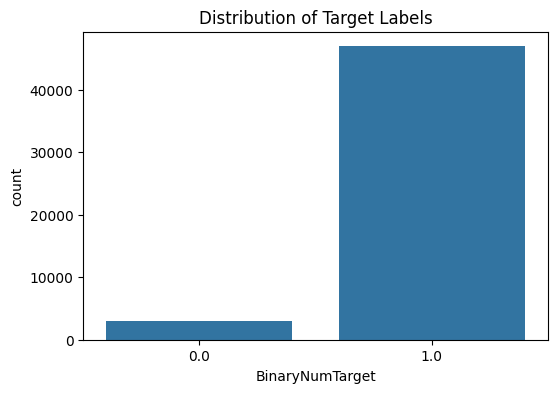

In [ ]:
#label count plot
plt.figure(figsize=(6,4))
sns.countplot(x=df_subset["BinaryNumTarget"])
plt.title("Distribution of Target Labels")
plt.show()

In [ ]:
#clean text
def clean_text(text):
    #checking if the input is a string
    if isinstance(text, str):
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)  #removes URLs
        text = re.sub(r"@\w+", "", text)                    #removes mentions
        text = re.sub(r"#\w+", "", text)                    #removes hashtags
        text = emoji.replace_emoji(text, "")                #removes emojis
        text = text.translate(str.maketrans("", "", string.punctuation))  #removes punctuation
        text = text.lower().strip()                         #converts text to lowercase and removes extra spaces
    return text

df_subset.loc[:, "clean_text"] = df_subset["tweet"].apply(clean_text)

In [ ]:
# Tweet length distribution
#calculate the length of each cleaned tweet
df_subset["tweet_length"] = df_subset["clean_text"].apply(lambda x: len(str(x).split()))

#plotting a histogram to visualize how many words tweets has
plt.figure(figsize=(6,4))
sns.histplot(df_subset["tweet_length"], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

In [ ]:
#plotting heatmap for all missing values
plt.figure(figsize=(8,4))
sns.heatmap(df_subset.isnull(), cbar=False)
plt.title("Missing Value Map")
plt.show()

In [ ]:
nltk.download("punkt") #helps NLTK split text into words/sentences
nltk.download("stopwords") #downloads a list of common english stopwords
stop_words = set(stopwords.words("english"))

In [ ]:
#function to remove stopwords from each tweet
def remove_stopwords(text):
    if not isinstance(text, str):
        return "" #return empty string if text is not valid
    #keep only words that are not in our stop_words list
    return " ".join([w for w in text.split() if w not in stop_words])

#apply stopword removal function to cleaned text column
df_subset["clean_text"] = df_subset["clean_text"].apply(remove_stopwords)

In [ ]:
# reduces words to their root form
stemmer = SnowballStemmer("english")

#function to stem words in text
def stem_text(text):
    if not isinstance(text, str):
        return "" #return empty string if input is not valid
    tokens = text.split()  #split text into words
    stems = [stemmer.stem(t) for t in tokens] #apply stemming to each word
    return " ".join(stems) #join back into a single string

#apply stemming to cleaned text and store it in a new column
df_subset["stem_text"] = df_subset["clean_text"].apply(stem_text)

In [ ]:
#counting rows before removing empty/invalid stemmed text
n_before = len(df_subset)
#drop rows where stem_text is empty
df_subset = df_subset[df_subset["stem_text"].str.strip() != ""].copy()
#counting rows after cleaning
n_after = len(df_subset)
#gives us how many rows were removed during this cleaning
print(f"Rows before: {n_before}, after removing empty stem_text: {n_after}, dropped: {n_before-n_after}")

In [ ]:
#select only numeric columns from dataset
numeric_cols = df_subset.select_dtypes(include=["int64","float64"]).columns.tolist()
#removes target column from this list
if "BinaryNumTarget" in numeric_cols:
    numeric_cols.remove("BinaryNumTarget")
#remove ID like columns as they don't carry meaningful information
for col in ["id","tweet_id","created_at"]:
    if col in numeric_cols:
        numeric_cols.remove(col)

In [ ]:
scaler = MinMaxScaler()
#applying scaling only if there are numeric columns present
if len(numeric_cols) > 0:
    df_subset[numeric_cols] = scaler.fit_transform(df_subset[numeric_cols])

In [ ]:
#creates a TF-IDF vectorizer to convert text into numerical features
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5, max_df=0.9)

#transforms stemmed tweets into a TF-IDF matrix
X_text = tfidf.fit_transform(df_subset["stem_text"].astype(str))

In [ ]:
#converts categories/text into numbers
le = LabelEncoder()
#fits encoder on target column and transform it into a new numeric column
df_subset["label_encoded"] = le.fit_transform(df_subset["BinaryNumTarget"].astype(str))

#saves mapping of original label to encoded number
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

In [ ]:
if len(numeric_cols) > 0:
    #extract numeric features as a NumPy array
    X_numeric = df_subset[numeric_cols].values
    #convert numeric features to a sparse matrix
    X_numeric_sparse = sp.csr_matrix(X_numeric)
    #horizontally stack text features and numeric features together
    X_final = sp.hstack((X_text, X_numeric_sparse), format="csr")
else:
    #if no numeric features exist, use only the TF-IDF text matrix
    X_final = X_text.tocsr()
#final target labels for modeling
y_final = df_subset["label_encoded"].values

In [ ]:
joblib.dump(tfidf, "tfidf_vectorizer.joblib") #saves TF-IDF vectorizer
joblib.dump(scaler, "scaler_minmax.joblib") #saves MinMax scaler for numeric features
joblib.dump(le, "label_encoder.joblib") #saves label encoder(0/1 mapping)

In [ ]:
#dividing data into training and testing
#20% for testing and 80% for training
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

In [ ]:
classes = np.unique(y_train) #find all unique class labels in the training set
#compute balanced class weights based on class frequency
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
#store weights in a dictionary
class_weights = dict(zip(classes, cw))
print("Class weights (for reporting):", class_weights)

In [ ]:
#calculate scale_pos_weight for XGBoost to handle class imbalance
scale_pos_weight = None
if len(classes) == 2: #only valid for binary classification
    scale_pos_weight = cw[1] / cw[0] #
    print("Suggested scale_pos_weight for XGBoost:", scale_pos_weight)

In [ ]:
#XGboost model
xgb_base = XGBClassifier(
    max_depth=6, #maximum depth of each tree
    learning_rate=0.1, #how fast model learns
    n_estimators=200, #number of trees to build
    subsample=0.8, #use 80% of rows per tree
    colsample_bytree=0.8, #use 80% of features per tree
    eval_metric='logloss', #evaluation metric for binary classification
    tree_method='hist'   #GPU-friendly
)

#train XGBoost model on training data
xgb_base.fit(X_train, y_train)

#makes predictions on test set
y_pred = xgb_base.predict(X_test)

In [ ]:
#evaluate  XGBoost model using various performance metrics

y_pred = xgb_base.predict(X_test) #model prediction for test set
print("For XGBoost model")
print("Baseline Accuracy:", accuracy_score(y_test, y_pred)) #overall correctness
print("Baseline Precision:", precision_score(y_test, y_pred, zero_division=0)) #how many predicted positives were correct
print("Baseline Recall:", recall_score(y_test, y_pred, zero_division=0)) #how well model finds actual positives
print("Baseline F1 Score:", f1_score(y_test, y_pred, zero_division=0)) #balance between precision & recall
print("Baseline Cohen's Kappa:", cohen_kappa_score(y_test, y_pred)) #agreement score between model and truth

# Report per class
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
#plotting confusion matrix for XGBoost
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
# if you have label encoder 'le', map ticks back to original labels
try:
    labels = list(le.inverse_transform([0,1]))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5,1.5], labels)
    plt.yticks([0.5,1.5], labels)
except Exception:
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.show()

In [ ]:
# Hyperparameter Tuning for XGBoost using GridSearchCV

#define set of parameters we want to try
params = {
    "max_depth": [4, 6, 8], # how deep each tree can grow
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200],  #number of boosting rounds
}

xgb_model = XGBClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss", #evaluation metric for binary classification
    tree_method="hist", #faster training
    use_label_encoder=False,
    random_state=42,
    # optionally: scale_pos_weight=scale_pos_weight
)

#performs grid search with cross validation
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=params, #parameter combinations to test
    cv=3, #3 fold cross validation
    scoring="f1", # Evaluate models based on F1-score
    verbose=1,
    n_jobs=-1
)

#train multiple models and find the best parameter combination
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score (f1):", grid.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:15:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Best CV Score (f1): 0.9999200714028517


In [ ]:
#train final Model with best parameters
best_params = grid.best_params_

xgb_final = XGBClassifier(
    **best_params, #inserts tuned parameters automatically
    subsample=0.8, #still keep these stable hyperparameters from before
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    use_label_encoder=False,
    random_state=42,
)

#train optimized model
xgb_final.fit(X_train, y_train)

#make predictions on test data using the final model
y_pred_final = xgb_final.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:15:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
#final evaluation of tuned XGBoost model
print("For XGBoost")
print("Final Model Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Precision:", precision_score(y_test, y_pred_final, zero_division=0))
print("Final Recall:", recall_score(y_test, y_pred_final, zero_division=0))
print("Final F1 Score:", f1_score(y_test, y_pred_final, zero_division=0))
print("Final Cohen's Kappa:", cohen_kappa_score(y_test, y_pred_final))

#performance for each class
print("\nFinal Classification Report:\n", classification_report(y_test, y_pred_final))

For XGBoost
Final Model Accuracy: 1.0
Final Precision: 1.0
Final Recall: 1.0
Final F1 Score: 1.0
Final Cohen's Kappa: 1.0

Final Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00      9416

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



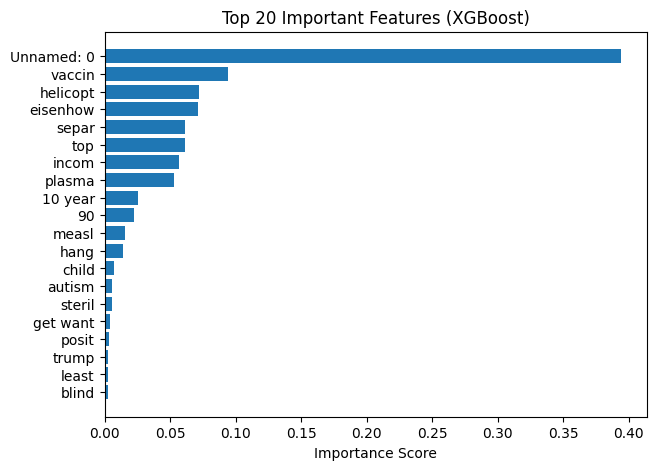

In [ ]:
#feature importance plot for final XGBoost model

#gets importance scores for all features
importances = xgb_final.feature_importances_

#selects top 20 features
top_k = 20
indices = np.argsort(importances)[-top_k:]
top_importance = importances[indices]

tfidf_feature_count = 0
tfidf_names = []
numeric_names = []
try:
    #number of TF-IDF text features
    tfidf_feature_count = X_text.shape[1] if 'X_text' in globals() else (len(tfidf.get_feature_names_out()) if 'tfidf' in globals() else 0)
    tfidf_names = tfidf.get_feature_names_out() if hasattr(tfidf, "get_feature_names_out") else []
except Exception as e:
    tfidf_feature_count = 0
    tfidf_names = []

try:
    #numeric feature names used in model
    numeric_names = numeric_cols if 'numeric_cols' in globals() else []
except Exception:
    numeric_names = []

def idx_to_name(idx):
    if idx < tfidf_feature_count:
        return tfidf_names[idx]
    else:
        num_idx = idx - tfidf_feature_count
        return numeric_names[num_idx] if num_idx < len(numeric_names) else f"feat_{idx}"

top_feature_names = [idx_to_name(i) for i in indices]

plt.figure(figsize=(7,5))
plt.barh(range(len(top_importance)), top_importance)
plt.yticks(range(len(top_importance)), top_feature_names)
plt.title(f"Top {top_k} Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.show()


In [ ]:
#prints top features and scores
print("\nTop features and their importance scores:")
for name, imp in zip(top_feature_names, top_importance):
    print(f"{name}: {imp:.6f}")


Top features and their importance scores:
blind: 0.002605
least: 0.002635
trump: 0.002855
posit: 0.003017
get want: 0.003762
steril: 0.005836
autism: 0.005907
child: 0.006875
hang: 0.013827
measl: 0.015884
90: 0.022755
10 year: 0.025568
plasma: 0.053286
incom: 0.056675
top: 0.061314
separ: 0.061583
eisenhow: 0.071503
helicopt: 0.072431
vaccin: 0.093929
Unnamed: 0: 0.394394


ROC-AUC Score: 1.0


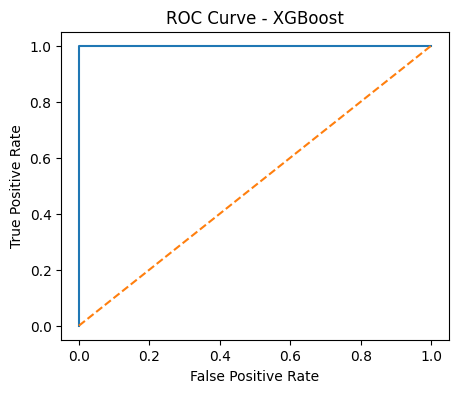

In [ ]:
#ROC curve/AUC score


y_proba = xgb_final.predict_proba(X_test)[:,1]

#compute AUC score
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", auc)

#calculates false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

#plotting ROC curve
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
#save trained final model for future use
joblib.dump(xgb_final, "xgb_final.joblib")
#save TF-IDF vectorizer if it exists in environment
if 'tfidf' in globals():
    joblib.dump(tfidf, "tfidf_vectorizer.joblib")
#save label encoder to decode predictions later
if 'le' in globals():
    joblib.dump(le, "label_encoder.joblib")
print("Saved model and artifacts")

Saved model and artifacts


In [ ]:
# Neural Network
#convert sparse CSR matrices to dense NumPy arrays
try:
# this may raise MemoryError on large datasets
    X_train_dense = X_train.toarray()
    X_test_dense = X_test.toarray()
    print("Converted sparse matrices to dense arrays: shapes", X_train_dense.shape, X_test_dense.shape)
    use_dense = True
except Exception as e:
#if conversion fails
    print("Couldn't convert to dense (memory). Exception:", e)
    use_dense = False

Converted sparse matrices to dense arrays: shapes (39997, 5002) (10000, 5002)


In [ ]:
if not use_dense:
    print("\nFALLBACK: Using sklearn MLP (handles sparse input better) OR reduce TF-IDF size and rerun.")
    from sklearn.neural_network import MLPClassifier
    mlp = MLPClassifier(hidden_layer_sizes=(256,128), activation='relu', max_iter=20, verbose=True)
    mlp.fit(X_train, y_train)
    y_pred_mlp = mlp.predict(X_test)

#added metrics for fallback MLP
    print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
    print("MLP Precision:", precision_score(y_test, y_pred_mlp, zero_division=0))
    print("MLP Recall:", recall_score(y_test, y_pred_mlp, zero_division=0))
    print("MLP F1 Score:", f1_score(y_test, y_pred_mlp, zero_division=0))
    print("MLP Cohen's Kappa:", cohen_kappa_score(y_test, y_pred_mlp))
    print(classification_report(y_test, y_pred_mlp))

#confusion matrix for fallback NLP
    cm = confusion_matrix(y_test, y_pred_mlp)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Confusion Matrix - sklearn MLP (fallback)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

else:

#build Keras model
    input_dim = X_train_dense.shape[1]
    print("Input dim for NN:", input_dim)

#compute class weights to handle imbalance
    classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weight_dict = {int(c): w for c, w in zip(classes, class_weights)}
    print("Class weights:", class_weight_dict)

Input dim for NN: 5002
Class weights: {0: np.float64(8.129471544715447), 1: np.float64(0.5327676692330234)}


In [ ]:
        #set random seed for reproducibility
        tf.random.set_seed(42)
        #sequential neural network for binary classification
        model = models.Sequential([
        layers.Input(shape=(input_dim,)), #input layer matching number of features
        layers.Dense(512, activation='relu'), #first dense layer with ReLU activation
        layers.BatchNormalization(),
        layers.Dropout(0.4), #40% nodes dropped
        layers.Dense(256, activation='relu'), #2nd hidden layer
        layers.BatchNormalization(),
        layers.Dropout(0.3), #drop to reduce overfitting
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')  #final layer with sigmoid for binary classification
    ])

        model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), #smaller layer to compress features
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
    )
#summary of model architecture
        model.summary()

#callbacks
#stop training early when validation AUC stops improving
        es = callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max', patience=3,
        restore_best_weights=True,
        verbose=1
    )

        rlrop = callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.5,
        patience=2,
        verbose=1
    )


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,561,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,712,449 (10.35 MB)

 Trainable params: 2,710,913 (10.34 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [ ]:
        #train neural network
        history = model.fit(
        X_train_dense, y_train,
        validation_split=0.1, #10% of training data used for validation
        epochs=15,
        batch_size=128,
        class_weight=class_weight_dict, #helps handle class imbalance
        callbacks=[es, rlrop],
        verbose=2
    )

Epoch 1/15
282/282 - 22s - 78ms/step - accuracy: 0.9661 - auc: 0.9981 - loss: 0.0611 - val_accuracy: 0.9467 - val_auc: 0.9999 - val_loss: 0.0995 - learning_rate: 1.0000e-03
Epoch 2/15
282/282 - 18s - 63ms/step - accuracy: 0.9979 - auc: 0.9999 - loss: 0.0063 - val_accuracy: 0.9990 - val_auc: 1.0000 - val_loss: 0.0031 - learning_rate: 1.0000e-03
Epoch 3/15

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
282/282 - 16s - 56ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 0.0024 - val_accuracy: 0.9980 - val_auc: 1.0000 - val_loss: 0.0057 - learning_rate: 1.0000e-03
Epoch 4/15
282/282 - 17s - 59ms/step - accuracy: 0.9996 - auc: 1.0000 - loss: 0.0012 - val_accuracy: 0.9980 - val_auc: 1.0000 - val_loss: 0.0047 - learning_rate: 5.0000e-04
Epoch 5/15

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
282/282 - 16s - 57ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 3.9883e-04 - val_accuracy: 0.9980 - val_auc: 1.0000 - val_loss: 0.0041 - lea

In [ ]:
        #evaluate neural network on test set

        #predicting probabilities for positive class
        y_proba_nn = model.predict(X_test_dense).ravel()
        #convert probabilities to class labels
        y_pred_nn = (y_proba_nn >= 0.5).astype(int)

        print("NN Test Accuracy:", accuracy_score(y_test, y_pred_nn))
        print("NN Precision:", precision_score(y_test, y_pred_nn, zero_division=0))
        print("NN Recall:", recall_score(y_test, y_pred_nn, zero_division=0))
        print("NN F1 Score:", f1_score(y_test, y_pred_nn, zero_division=0))
        print("NN Cohen's Kappa:", cohen_kappa_score(y_test, y_pred_nn))

        #full performace for each class
        print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
NN Test Accuracy: 0.9985
NN Precision: 0.9998936509624587
NN Recall: 0.9985131690739167
NN F1 Score: 0.9992029332058027
NN Cohen's Kappa: 0.9865019350825865

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       584
           1       1.00      1.00      1.00      9416

    accuracy                           1.00     10000
   macro avg       0.99      1.00      0.99     10000
weighted avg       1.00      1.00      1.00     10000



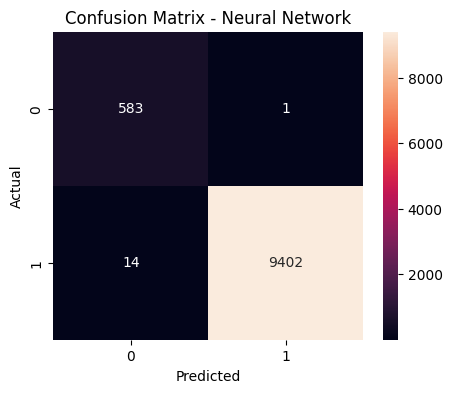

In [ ]:
    #confusion matrix for neural networks

    #create confusion matrix comparing true vs predicted labels
    cm = confusion_matrix(y_test, y_pred_nn)
    #plotting heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix - Neural Network")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

NN ROC-AUC: 0.999990543638924


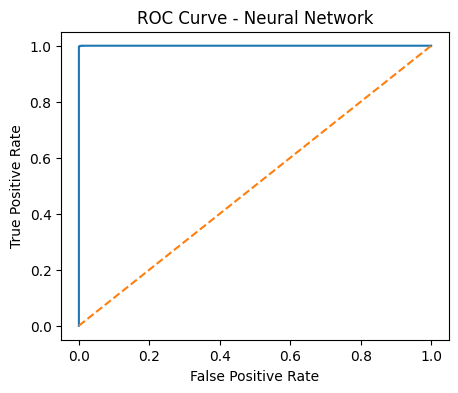

In [ ]:
    # ROC curve and AUC curve for neural network

    #compute AUC score using predicted probabilities
    auc_nn = roc_auc_score(y_test, y_proba_nn)
    print("NN ROC-AUC:", auc_nn)
    #ROC curve values
    fpr, tpr, _ = roc_curve(y_test, y_proba_nn)
    #plot ROC curve
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.title("ROC Curve - Neural Network")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

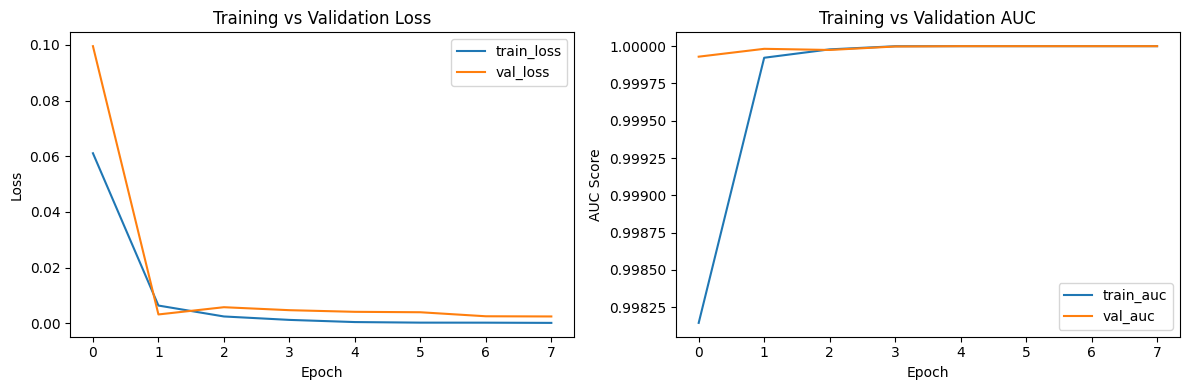

In [ ]:
    plt.figure(figsize=(12,4))

    #plotting Loss curve
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    #plotting AUC curve
    plt.subplot(1,2,2)
    plt.plot(history.history['auc'], label='train_auc')
    plt.plot(history.history['val_auc'], label='val_auc')
    plt.title('Training vs Validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC Score')
    plt.legend()

    plt.tight_layout()
    plt.show()

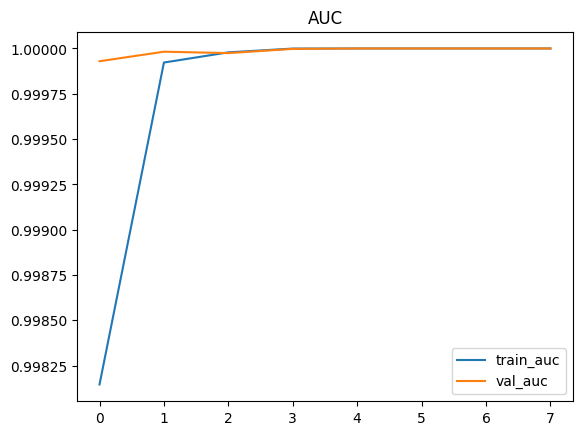

In [ ]:
    #checking if auc is present
    if 'auc' in history.history:
        plt.plot(history.history['auc'], label='train_auc')
    if 'val_auc' in history.history:
        plt.plot(history.history['val_auc'], label='val_auc')
    plt.title('AUC')
    plt.legend()
    plt.show()

In [ ]:
    #save model
    model.save("xtruth_neural_model.h5")
    print("Saved model to xtruth_neural_model.h5")

Saved model to xtruth_neural_model.h5


In [ ]:
#print versions
import pkg_resources
print("numpy", np.__version__)
print("xgboost", xgb.__version__ if hasattr(xgb, "__version__") else "unknown")
print("tensorflow", tf.__version__)

/tmp/ipython-input-902022274.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


numpy 2.0.2
xgboost 3.1.2
tensorflow 2.19.0


In [ ]:
try:
    #new sklearn version
    tfidf_feature_names = list(tfidf.get_feature_names_out())
except Exception:
    #old sklearn fallback
    try:
        tfidf_feature_names = list(tfidf.get_feature_names())
    #if both methods fail then warn user and use empty list
    except Exception:
        tfidf_feature_names = []
        print("Warning: tfidf feature names unavailable. Feature names will be generic.")

#numeric_cols should exist from earlier preprocessing; ensure it's a list
try:
    numeric_feature_names = list(numeric_cols)
except Exception:
    numeric_feature_names = []
    print("Warning: numeric_cols missing — numeric_feature_names set empty.")


#combining TF-IDF and numeric feature names
feature_names = tfidf_feature_names + numeric_feature_names

#summary for debugging
print("Total features:", len(feature_names), " (tfidf:", len(tfidf_feature_names), " numeric:", len(numeric_feature_names), ")")

Total features: 5002  (tfidf: 5000  numeric: 2 )


In [ ]:
N_BACKGROUND = 500  #no. of samples to use for LIME

# Determine how many samples are in X_train
if sp.issparse(X_train):
    n_train = X_train.shape[0]
else:
    n_train = len(X_train)

#if requested sample size is bigger than training data then  adjust safely
if N_BACKGROUND > n_train:
    N_BACKGROUND = n_train
    print(f"N_BACKGROUND adjusted to training size: {N_BACKGROUND}")

#random generator for reproducibility
rng = np.random.RandomState(42)
if sp.issparse(X_train):
    #for sparse training data
    if X_train.shape[0] > N_BACKGROUND:
        ids = rng.choice(X_train.shape[0], size=N_BACKGROUND, replace=False)
    else:
        ids = np.arange(X_train.shape[0])
    X_train_sample = X_train[ids].toarray()
else:
    #for dense arrays or lists
    if len(X_train) > N_BACKGROUND:
        ids = rng.choice(len(X_train), size=N_BACKGROUND, replace=False)
    else:
        ids = np.arange(len(X_train))
    X_train_sample = np.asarray(X_train)[ids]

print("Background sample shape:", X_train_sample.shape)


Background sample shape: (500, 5002)


In [ ]:
try:
    class_names = list(le.inverse_transform([0,1])) if ('le' in globals() and len(le.classes_)==2) else ["class_0","class_1"]
except Exception:
    class_names = ["class_0","class_1"]

#ensure feature_names length equals number of columns in X_train_sample
if X_train_sample.shape[1] != len(feature_names):
    print("Warning: feature_names length != X_train columns. Creating generic feature names to match dimensions.")
    feature_names = [f"f_{i}" for i in range(X_train_sample.shape[1])]

#creating lime tabular explainer
explainer = LimeTabularExplainer(
    training_data=X_train_sample,
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    verbose=True,
    mode='classification'
)

In [ ]:
#this function safely handles both sparse and dense inputs
def get_dense_instance(X, idx):
    """Return dense numpy array for the test instance at idx (row index within X_test)."""
    if sp.issparse(X):
        return X[idx].toarray().ravel()
    else:
        return np.asarray(X[idx]).ravel()

In [ ]:
#prediction wrappers LIME will call
def predict_proba_xgb(array_2d):
    """
    array_2d: numpy array (n_rows, n_features)
    returns: numpy array (n_rows, 2) with probs for [class0, class1]
    """
    arr = np.asarray(array_2d) #ensures input is numpy array
    probs = xgb_final.predict_proba(arr) #XGBoost returns shape
    return probs

def predict_proba_nn(array_2d):
    """
    array_2d: numpy array (n_rows, n_features)
    returns: numpy array (n_rows, 2) with probs for [class0, class1]
    """
    arr = np.asarray(array_2d) #ensures input is numpy
    p1 = model.predict(arr, verbose=0).ravel()
    p0 = 1.0 - p1
    probs = np.vstack([p0, p1]).T
    return probs

In [ ]:
#prediction wrapper for the sklearn MLP
def predict_proba_mlp(array_2d):
    arr = np.asarray(array_2d)
    return mlp.predict_proba(arr)

In [ ]:
#Selects a test instance to explain with LIME

#choose which sample to explain
INSTANCE_IDX = 10
if INSTANCE_IDX < 0 or INSTANCE_IDX >= (X_test.shape[0] if not sp.issparse(X_test) else X_test.shape[0]):
    INSTANCE_IDX = 0
    print("INSTANCE_IDX out of range — reset to 0.")

#fetch single test instance as a dense 1D array
instance_dense = get_dense_instance(X_test, INSTANCE_IDX)

In [ ]:
#LIME Explanation for XGBoost prediction
exp_xgb = explainer.explain_instance(
    data_row=instance_dense,
    predict_fn=predict_proba_xgb,
    num_features=20,
    top_labels=1
)

#converts explanation to HTML
html_xgb = exp_xgb.as_html()

#saves explanation as an HTML file
with open("lime_xgb_explanation.html","w",encoding="utf-8") as f:
    f.write(html_xgb)
print("Saved XGBoost LIME explanation to lime_xgb_explanation.html")
display(HTML(html_xgb))

#raw feature contributions
print("XGBoost - local feature contributions (feature, weight):")
print(exp_xgb.as_list(label=exp_xgb.available_labels()[0]))

Intercept -1.3993537032211332
Prediction_local [0.78944656]
Right: 0.9998254
Saved XGBoost LIME explanation to lime_xgb_explanation.html


XGBoost - local feature contributions (feature, weight):
[('decrimin <= 0.00', 0.30059119036471615), ('daughter <= 0.00', 0.2173118901639037), ('oil <= 0.00', 0.21720571671222227), ('context <= 0.00', 0.21357790798594836), ('system racism <= 0.00', 0.213281104437095), ('tax state <= 0.00', 0.21298604044058117), ('obtain <= 0.00', 0.18619744570652808), ('vote mexico > 0.00', -0.1765697007470631), ('rich <= 0.00', 0.16703240767518068), ('stock ppe <= 0.00', 0.13353802514603116), ('proactiv know <= 0.00', 0.13341622779306642), ('trump call <= 0.00', 0.13143834513862515), ('one reason <= 0.00', 0.10993892385481621), ('doctor <= 0.00', 0.09235562474921781), ('transit <= 0.00', 0.08242187284401434), ('reason provid <= 0.00', -0.04071727376126031), ('two unpopular <= 0.00', 0.03235751151421773), ('feder tax <= 0.00', -0.02813641302871139), ('intend <= 0.00', -0.022468568822390598), ('blue state <= 0.00', 0.013041984095951127)]


In [ ]:
# LIME Explanation for Neural Network prediction
exp_nn = explainer.explain_instance(
    data_row=instance_dense,
    predict_fn=predict_proba_nn,
    num_features=20,
    top_labels=1
)

# Converts explanation to HTML
html_nn = exp_nn.as_html()

# Saves explanation as an HTML file
with open("lime_nn_explanation.html","w",encoding="utf-8") as f:
    f.write(html_nn)
print("Saved NN LIME explanation to lime_nn_explanation.html")
display(HTML(html_nn))

print("Neural Network - local feature contributions (feature, weight):")
print(exp_nn.as_list(label=exp_nn.available_labels()[0]))

Intercept 0.4068436375452753
Prediction_local [0.60780837]
Right: 0.9999978
Saved NN LIME explanation to lime_nn_explanation.html


Neural Network - local feature contributions (feature, weight):
[('Unnamed: 0 > 0.74', -0.35888941668947066), ('286 <= 0.00', 0.34140389973674756), ('today minimum <= 0.00', 0.2840559017159618), ('rescu plan <= 0.00', -0.24673609484108625), ('dont believ <= 0.00', 0.23115990544652842), ('twobedroom apart <= 0.00', 0.19402065952537884), ('household incom <= 0.00', 0.18857790486068526), ('pick <= 0.00', -0.18190834142492077), ('margaret <= 0.00', -0.16066967174023308), ('embarrass <= 0.00', -0.13502123673386793), ('lockdown <= 0.00', 0.12427197262675979), ('specif <= 0.00', 0.11479792826459846), ('gdp <= 0.00', -0.09528276711108845), ('ban china <= 0.00', 0.08197690885050275), ('field <= 0.00', -0.07940145848166079), ('bibl one <= 0.00', -0.06908356590613121), ('offend <= 0.00', 0.05156861258937329), ('crimin convict <= 0.00', -0.04425509240255707), ('advoc <= 0.00', -0.028382302610725572), ('facebook <= 0.00', -0.011239016883972972)]


In [ ]:
TEXT_COL = "stem_text"

def build_combined_text(series, extra_stopwords=set()):
    stopwords = set(STOPWORDS) | extra_stopwords
    all_text = " ".join(str(t) for t in series.dropna().astype(str).values)
    tokens = [tok for tok in all_text.split() if len(tok) > 1 and tok.lower() not in stopwords]
    return " ".join(tokens)

extra_stop = {"rt", "https", "http", "amp"}

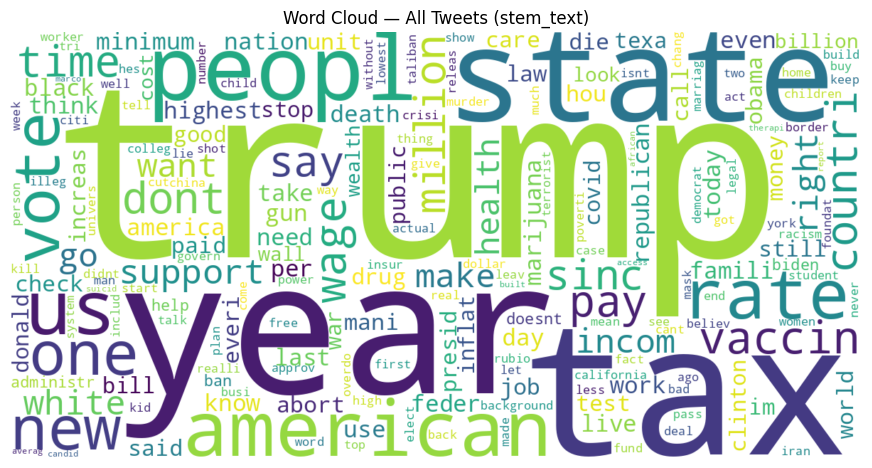

Saved wordcloud_all.png


In [ ]:
#overall word cloud
combined = build_combined_text(df_subset[TEXT_COL], extra_stopwords=extra_stop)
wc = WordCloud(width=1200, height=600, background_color="white",
               collocations=False, max_words=200).generate(combined)

plt.figure(figsize=(11,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — All Tweets (" + TEXT_COL + ")")
plt.show()
wc.to_file("wordcloud_all.png")
print("Saved wordcloud_all.png")

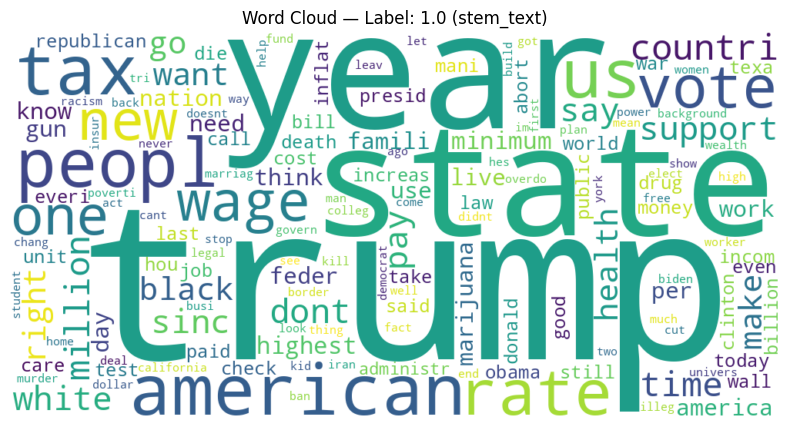

Saved wordcloud_label_1.0.png


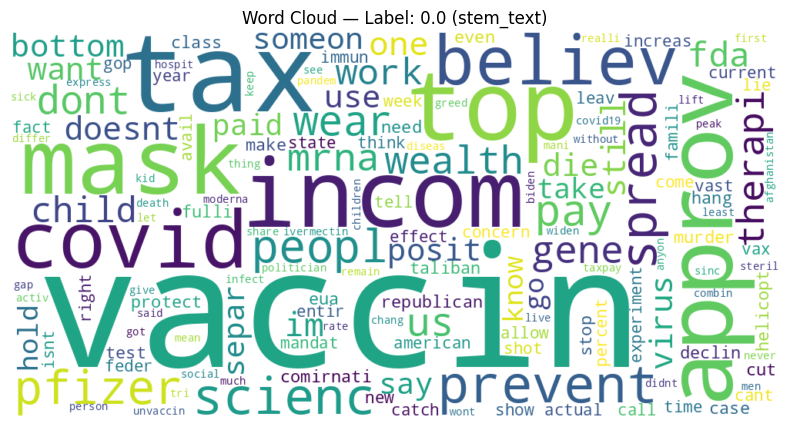

Saved wordcloud_label_0.0.png


In [ ]:
#word clouds by label
labels_column = "BinaryNumTarget"

unique_labels = df_subset[labels_column].unique()
for lab in unique_labels:
    text_lab = build_combined_text(df_subset[df_subset[labels_column] == lab][TEXT_COL],
                                   extra_stopwords=extra_stop)
    wc_lab = WordCloud(width=1000, height=500, background_color="white",
                       collocations=False, max_words=150).generate(text_lab)
    plt.figure(figsize=(12,5))
    plt.imshow(wc_lab, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud — Label: {lab} ({TEXT_COL})")
    plt.show()
    filename = f"wordcloud_label_{str(lab)}.png"
    wc_lab.to_file(filename)
    print("Saved", filename)